# Isolation Forest for Fraud Anomaly Detection

This script uses the unified_dataset.csv and applies an Isolation Forest algorithm for fraud anomaly detection. The Isolation Forest is an unsupervised learning algorithm that identifies anomalies by isolating observations. It works on the principle that anomalies are few and different, making them easier to isolate in a tree structure.

The notebook includes:
- Data preprocessing with standard scaling
- **AUPRC-based hyperparameter tuning** (uses labeled fraud samples for validation)
- Anomaly score analysis
- Feature importance for anomaly detection
- Visualization of detected anomalies
- **Confusion matrix based on top 5% anomalous threshold**
- **Model export for ensemble integration**

The test data is 40% of the original data.

In [1]:
!pip install --upgrade scikit-learn

     |████████████████████████████████| 23.0MB 3.4MB/s eta 0:00:01
     |████████████████████████████████| 307kB 65.3MB/s eta 0:00:01
  Found existing installation: scikit-learn 0.20.3
    Uninstalling scikit-learn-0.20.3:
      Successfully uninstalled scikit-learn-0.20.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load and Prepare Data

In [3]:
# Load the dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (140827, 69)

First few rows:


,npi,rfrg_prvdr_state_abrvtn,target,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplrs_median,tot_suplrs_min,tot_suplr_clms_min,...,tot_suplr_benes_sum_zscore_by_type,tot_suplr_srvcs_max_zscore,total_payment_zscore_by_type,bene_avg_age_zscore_by_type,bene_avg_risk_scre_zscore_by_type,submitted_to_standardized_ratio_zscore,submitted_to_standardized_ratio_zscore_by_type,claims_per_bene_zscore_by_type,services_per_bene_zscore_by_type,benes_per_supplier_zscore_by_type
0,1003000597,OK,0,1.692306,1.692306,1.692306,1.0,3.0,3,44,...,-0.275616,-0.007007,-0.008424,-0.549574,-0.210703,-0.038129,-0.154682,3.003923,4.288024,-0.187419
1,1003000597,OK,0,23.833223,0.112054,8.331875,5.0,3.0,1,17,...,-0.219804,0.045155,-0.010997,-0.115403,-0.311213,-0.082280,-0.424691,1.564890,2.626744,-0.159271
2,1003000902,KY,0,155.711788,0.087436,82.163333,5.0,2.5,1,12,...,-0.145469,-0.091197,-0.065875,-0.363841,0.187261,0.015906,-0.018203,-0.036876,-0.073170,-0.092180
3,1003000902,KY,0,67.361088,0.028794,38.227500,4.0,3.0,1,11,...,-0.261960,-0.075164,-0.073111,-1.214294,-0.554692,0.061148,0.299657,-0.374303,0.108292,-0.098162
4,1003000902,KY,0,40.802223,0.098643,24.145333,3.0,3.5,1,11,...,-0.344188,-0.088898,-0.059281,-0.835965,-0.337922,-0.029850,-0.339677,-0.049636,0.152416,-0.091872


In [4]:
# Check for missing values
print("Missing values per column (top 20):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Missing values per column (top 20):
benes_per_supplier_zscore_by_type                                0
bene_cc_bh_tobacco_v1_pct                                        0
infusion_pumps_and_supplies                                      0
other_supplies_including_diabetes_supplies_and_contraceptives    0
oxygen_delivery_systems_and_related_supplies                     0
wheelchairs_components_and_accessories                           0
bene_race_api_cnt                                                0
bene_dual_cnt                                                    0
bene_cc_bh_alz_non_alzdem_v2_pct                                 0
bene_cc_ph_hyperlipidemia_v2_pct                                 0
bene_cc_bh_anxiety_v1_pct                                        0
bene_cc_bh_schizo_oth_psy_v1_pct                                 0
bene_cc_ph_asthma_v2_pct                                         0
bene_cc_ph_ckd_v2_pct                                            0
bene_cc_ph_copd_v2_pct    

In [5]:
# Define columns to exclude from modeling
# These are identifiers, targets, or non-predictive columns
exclude_cols = ['target', 'npi', 'year', 'Rfrg_NPI', 'covered_recipient_npi', 
                'fraud_flag', 'year_leie', 'excltype']

# Also exclude date columns
date_cols = [col for col in df.columns if 'date' in col.lower()]
exclude_cols.extend(date_cols)

# Select only numeric columns, excluding identifiers and target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Excluded columns: {[c for c in exclude_cols if c in df.columns]}")

# Create feature matrix
X = df[feature_cols].copy()

Number of feature columns: 64
Excluded columns: ['target', 'npi']


## Train-Test Split and Scaling

In [6]:
# Split data: 60% train, 40% test (stratified on target to preserve fraud ratio)
y = df['target'].values

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, X.index, test_size=0.4, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFraud in training set: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Fraud in test set: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Training set size: 84496 samples
Test set size: 56331 samples

Fraud in training set: 34 (0.0402%)
Fraud in test set: 22 (0.0391%)


In [7]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"\nTraining data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features scaled using StandardScaler

Training data - Mean: 0.0000, Std: 1.0000
Test data - Mean: -0.0019, Std: 1.0499


## AUPRC-Based Hyperparameter Tuning

Since we have a small set of labeled fraud samples (target=1), we use **Area Under the Precision-Recall Curve (AUPRC)** to tune hyperparameters:
- Train the Isolation Forest unsupervised (it doesn't use labels)
- Evaluate anomaly scores against the known fraud labels using AUPRC
- AUPRC is ideal for highly imbalanced data where positive cases are rare
- We use stratified K-fold cross-validation to ensure fraud cases appear in every fold

In [8]:
def compute_auprc_score(X_data, y_data, params, n_splits=5):
    """
    Compute mean AUPRC for a given parameter set using stratified K-fold CV.
    
    The Isolation Forest trains unsupervised, but we evaluate its anomaly
    scores against the known fraud labels using AUPRC.
    
    Returns:
        mean_auprc: Average AUPRC across folds
        std_auprc: Standard deviation of AUPRC across folds
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auprc_scores = []
    
    for fold_train_idx, fold_val_idx in skf.split(X_data, y_data):
        X_fold_train = X_data[fold_train_idx]
        X_fold_val = X_data[fold_val_idx]
        y_fold_val = y_data[fold_val_idx]
        
        # Skip folds with no positive samples in validation
        if y_fold_val.sum() == 0:
            continue
        
        model = IsolationForest(
            n_estimators=params['n_estimators'],
            max_samples=params['max_samples'],
            contamination=params['contamination'],
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_fold_train)
        
        # Get anomaly scores (negate so higher = more anomalous = more likely fraud)
        val_scores = -model.decision_function(X_fold_val)
        
        # Compute AUPRC: anomaly scores as predictions, fraud labels as ground truth
        auprc = average_precision_score(y_fold_val, val_scores)
        auprc_scores.append(auprc)
    
    return np.mean(auprc_scores), np.std(auprc_scores)

print("AUPRC scoring function defined.")

AUPRC scoring function defined.


In [9]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.5, 0.75, 1.0],
    'contamination': [0.001, 0.002, 0.005]
}

print(f"Running AUPRC-based hyperparameter tuning...")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Fraud samples in training: {y_train.sum()}")
print(f"Parameter combinations: {len(list(ParameterGrid(param_grid)))}")
print(f"Cross-validation folds: 5 (stratified)")

Running AUPRC-based hyperparameter tuning...
Training samples: 84496
Fraud samples in training: 34
Parameter combinations: 27
Cross-validation folds: 5 (stratified)


In [13]:
##############################################
# Run AUPRC-based grid search
###############################################
auprc_results = []

for params in ParameterGrid(param_grid):
    mean_auprc, std_auprc = compute_auprc_score(
        X_train_scaled, y_train, params, n_splits=5
    )
    
    auprc_results.append({
        **params,
        'mean_auprc': mean_auprc,
        'std_auprc': std_auprc
    })
    
    print(f"n_estimators={params['n_estimators']}, max_samples={params['max_samples']}, "
          f"contamination={params['contamination']} -> AUPRC: {mean_auprc:.4f} (+/- {std_auprc:.4f})")

# Convert to DataFrame and sort
auprc_df = pd.DataFrame(auprc_results).sort_values('mean_auprc', ascending=False)

print("\nTop 5 Parameter Combinations by AUPRC:")
print(auprc_df.head())

n_estimators=100, max_samples=0.5, contamination=0.001 -> AUPRC: 0.0014 (+/- 0.0012)
n_estimators=200, max_samples=0.5, contamination=0.001 -> AUPRC: 0.0013 (+/- 0.0011)
n_estimators=300, max_samples=0.5, contamination=0.001 -> AUPRC: 0.0012 (+/- 0.0009)
n_estimators=100, max_samples=0.75, contamination=0.001 -> AUPRC: 0.0014 (+/- 0.0014)
n_estimators=200, max_samples=0.75, contamination=0.001 -> AUPRC: 0.0014 (+/- 0.0013)
n_estimators=300, max_samples=0.75, contamination=0.001 -> AUPRC: 0.0013 (+/- 0.0013)
n_estimators=100, max_samples=1.0, contamination=0.001 -> AUPRC: 0.0015 (+/- 0.0011)
n_estimators=200, max_samples=1.0, contamination=0.001 -> AUPRC: 0.0014 (+/- 0.0011)
n_estimators=300, max_samples=1.0, contamination=0.001 -> AUPRC: 0.0014 (+/- 0.0011)
n_estimators=100, max_samples=0.5, contamination=0.002 -> AUPRC: 0.0014 (+/- 0.0012)
n_estimators=200, max_samples=0.5, contamination=0.002 -> AUPRC: 0.0013 (+/- 0.0011)
n_estimators=300, max_samples=0.5, contamination=0.002 -> AUPR

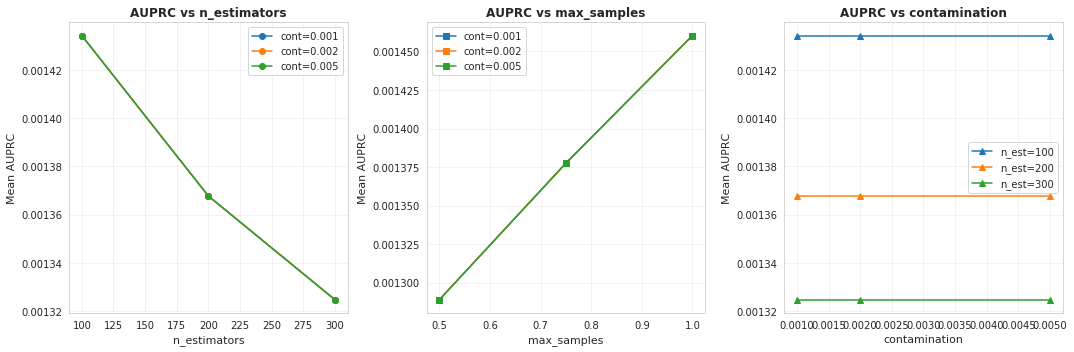

In [14]:
# Visualize AUPRC results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: AUPRC by n_estimators
for cont in param_grid['contamination']:
    subset = auprc_df[auprc_df['contamination'] == cont]
    grouped = subset.groupby('n_estimators')['mean_auprc'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'cont={cont}')
axes[0].set_xlabel('n_estimators', fontsize=11)
axes[0].set_ylabel('Mean AUPRC', fontsize=11)
axes[0].set_title('AUPRC vs n_estimators', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: AUPRC by max_samples
for cont in param_grid['contamination']:
    subset = auprc_df[auprc_df['contamination'] == cont]
    grouped = subset.groupby('max_samples')['mean_auprc'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='s', label=f'cont={cont}')
axes[1].set_xlabel('max_samples', fontsize=11)
axes[1].set_ylabel('Mean AUPRC', fontsize=11)
axes[1].set_title('AUPRC vs max_samples', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: AUPRC by contamination
for n_est in param_grid['n_estimators']:
    subset = auprc_df[auprc_df['n_estimators'] == n_est]
    grouped = subset.groupby('contamination')['mean_auprc'].mean()
    axes[2].plot(grouped.index, grouped.values, marker='^', label=f'n_est={n_est}')
axes[2].set_xlabel('contamination', fontsize=11)
axes[2].set_ylabel('Mean AUPRC', fontsize=11)
axes[2].set_title('AUPRC vs contamination', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('isolation_forest_auprc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
##############################################
# Select best parameters
###############################################
best_row = auprc_df.iloc[0]
best_params = best_row.to_dict()
best_auprc = best_params.pop('mean_auprc')
best_auprc_std = best_params.pop('std_auprc')

# Convert to proper types
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_samples'] = float(best_params['max_samples'])
best_params['contamination'] = float(best_params['contamination'])

print("Best Parameters (Highest AUPRC):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nAUPRC: {best_auprc:.4f} (+/- {best_auprc_std:.4f})")

Best Parameters (Highest AUPRC):
  contamination: 0.002
  max_samples: 1.0
  n_estimators: 100

AUPRC: 0.0015 (+/- 0.0011)


## Train Final Model with Best Parameters

In [16]:
##############################################
# Train Final Model
###############################################
print("Training final Isolation Forest model with best parameters...")

iso_forest = IsolationForest(
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    contamination=best_params['contamination'],
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_scaled)

Training final Isolation Forest model with best parameters...


IsolationForest(contamination=0.002, max_samples=1.0, n_jobs=-1,
                random_state=42)

In [17]:
# Get predictions and scores
train_predictions = iso_forest.predict(X_train_scaled)  # 1 = normal, -1 = anomaly
test_predictions = iso_forest.predict(X_test_scaled)

# Get anomaly scores (more negative = more anomalous in sklearn)
# We negate so that higher = more anomalous (for consistency with ensemble)
train_scores = -iso_forest.decision_function(X_train_scaled)
test_scores = -iso_forest.decision_function(X_test_scaled)

# Count anomalies
n_anomalies_train = (train_predictions == -1).sum()
n_anomalies_test = (test_predictions == -1).sum()

print(f"Training set anomalies: {n_anomalies_train} ({n_anomalies_train/len(train_predictions)*100:.2f}%)")
print(f"Test set anomalies: {n_anomalies_test} ({n_anomalies_test/len(test_predictions)*100:.2f}%)")

Training set anomalies: 169 (0.20%)
Test set anomalies: 120 (0.21%)


## Anomaly Score Distribution Analysis

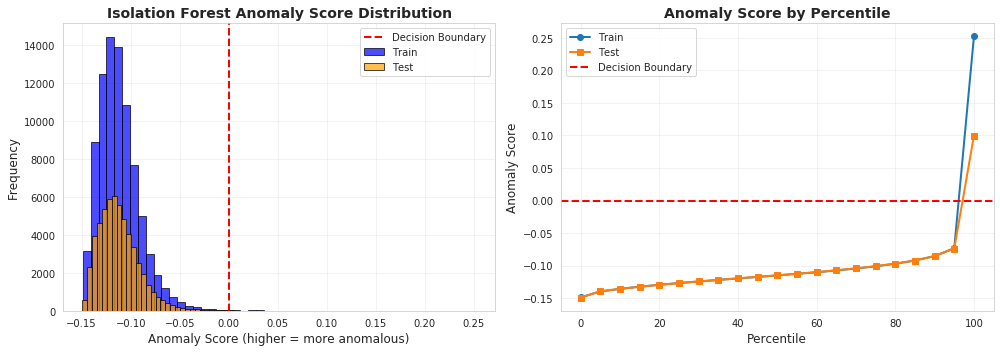

In [18]:
##############################################
# Viz Anomaly Scores
###############################################
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score distribution histogram
axes[0].hist(train_scores, bins=50, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(test_scores, bins=50, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Isolation Forest Anomaly Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Score by percentile
percentiles = np.arange(0, 101, 5)
train_percentile_scores = np.percentile(train_scores, percentiles)
test_percentile_scores = np.percentile(test_scores, percentiles)

axes[1].plot(percentiles, train_percentile_scores, marker='o', label='Train', linewidth=2)
axes[1].plot(percentiles, test_percentile_scores, marker='s', label='Test', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('Anomaly Score', fontsize=12)
axes[1].set_title('Anomaly Score by Percentile', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('isolation_forest_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Score statistics
print("Isolation Forest Score Statistics:")
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")

print(f"{'Mean':<20} {train_scores.mean():>12.4f} {test_scores.mean():>12.4f}")
print(f"{'Std':<20} {train_scores.std():>12.4f} {test_scores.std():>12.4f}")
print(f"{'Min':<20} {train_scores.min():>12.4f} {test_scores.min():>12.4f}")
print(f"{'25th Percentile':<20} {np.percentile(train_scores, 25):>12.4f} {np.percentile(test_scores, 25):>12.4f}")
print(f"{'Median':<20} {np.median(train_scores):>12.4f} {np.median(test_scores):>12.4f}")
print(f"{'75th Percentile':<20} {np.percentile(train_scores, 75):>12.4f} {np.percentile(test_scores, 75):>12.4f}")
print(f"{'95th Percentile':<20} {np.percentile(train_scores, 95):>12.4f} {np.percentile(test_scores, 95):>12.4f}")
print(f"{'99th Percentile':<20} {np.percentile(train_scores, 99):>12.4f} {np.percentile(test_scores, 99):>12.4f}")
print(f"{'Max':<20} {train_scores.max():>12.4f} {test_scores.max():>12.4f}")

Isolation Forest Score Statistics:
Metric                      Train         Test
Mean                      -0.1117      -0.1117
Std                        0.0216       0.0215
Min                       -0.1488      -0.1492
25th Percentile           -0.1267      -0.1268
Median                    -0.1149      -0.1149
75th Percentile           -0.1010      -0.1007
95th Percentile           -0.0731      -0.0737
99th Percentile           -0.0436      -0.0438
Max                        0.2520       0.0997


## Feature Importance Analysis

In [20]:
##############################################
# Analyze which features differentiate anomalies from normal samples
###############################################

anomaly_mask = test_predictions == -1
normal_mask = test_predictions == 1

# Calculate mean values for each group
normal_means = X_test_scaled[normal_mask].mean(axis=0)
anomaly_means = X_test_scaled[anomaly_mask].mean(axis=0)

# Calculate absolute difference
feature_importance = np.abs(anomaly_means - normal_means)

# Create DataFrame for easier analysis
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance,
    'normal_mean': normal_means,
    'anomaly_mean': anomaly_means,
    'difference': anomaly_means - normal_means
}).sort_values('importance', ascending=False)

print("Top 20 Features Differentiating Anomalies from Normal Samples:")
print(importance_df.head(20))

Top 20 Features Differentiating Anomalies from Normal Samples:
                                              feature  importance  \
2                         avg_suplr_mdcr_pymt_amt_max    7.332833   
0                         avg_suplr_mdcr_pymt_amt_sum    7.129935   
37               third_party_recipient_sum_individual    6.833675   
1                         avg_suplr_mdcr_pymt_amt_min    6.576031   
55                         tot_suplr_srvcs_max_zscore    6.310074   
52           avg_suplr_sbmtd_chrg_mean_zscore_by_type    5.981383   
10                                 tot_suplr_clms_max    5.586379   
53            avg_suplr_sbmtd_chrg_max_zscore_by_type    5.540011   
9                                 tot_suplr_benes_max    4.690241   
54                 tot_suplr_benes_sum_zscore_by_type    4.593147   
20                                      bene_dual_cnt    4.454577   
7                                 tot_suplr_srvcs_min    3.829269   
39                                 benes

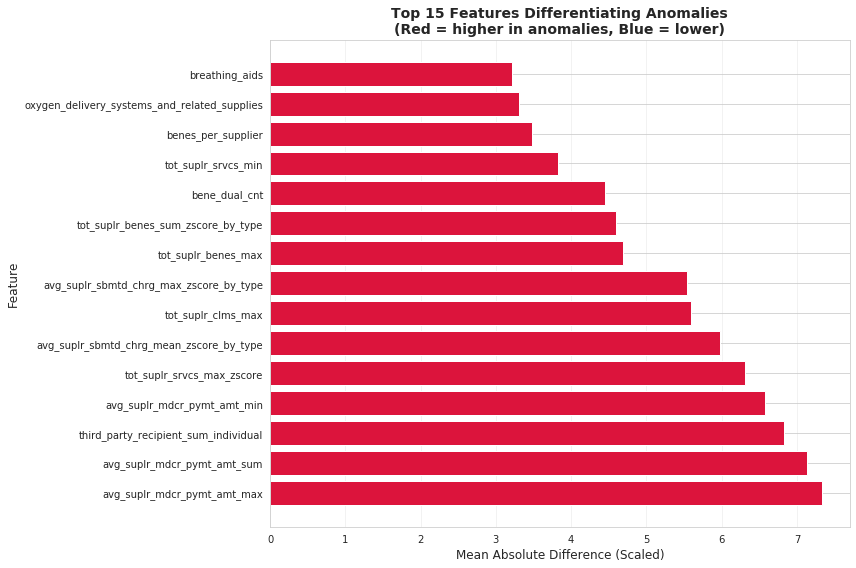

In [21]:
# Visualize top features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['crimson' if d > 0 else 'steelblue' for d in top_features['difference'].values]
plt.barh(range(top_n), top_features['importance'].values, color=colors)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Mean Absolute Difference (Scaled)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features Differentiating Anomalies\n(Red = higher in anomalies, Blue = lower)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# plt.savefig('isolation_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualize Anomalies with PCA

In [22]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA Explained Variance Ratio: [0.16559954 0.10940836]
Total variance explained: 27.50%


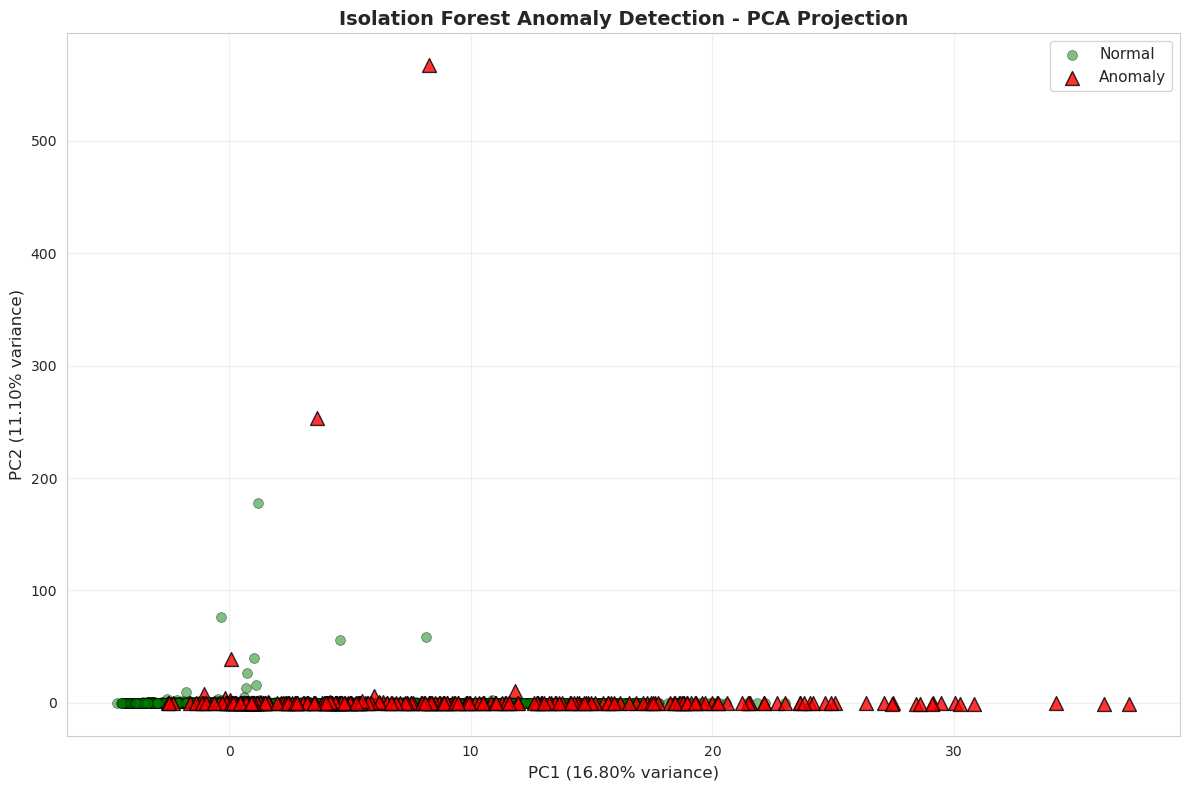

In [20]:
# Create visualization
plt.figure(figsize=(12, 8))

# Plot normal samples
normal_samples = X_test_pca[test_predictions == 1]
plt.scatter(normal_samples[:, 0], normal_samples[:, 1], 
            c='green', s=50, alpha=0.5, label='Normal', edgecolors='k', linewidth=0.5)

# Plot anomalies
anomaly_samples = X_test_pca[test_predictions == -1]
plt.scatter(anomaly_samples[:, 0], anomaly_samples[:, 1], 
            c='red', s=100, alpha=0.8, label='Anomaly', edgecolors='k', linewidth=1, marker='^')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Isolation Forest Anomaly Detection - PCA Projection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('isolation_forest_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly Score Heatmap for Top Features

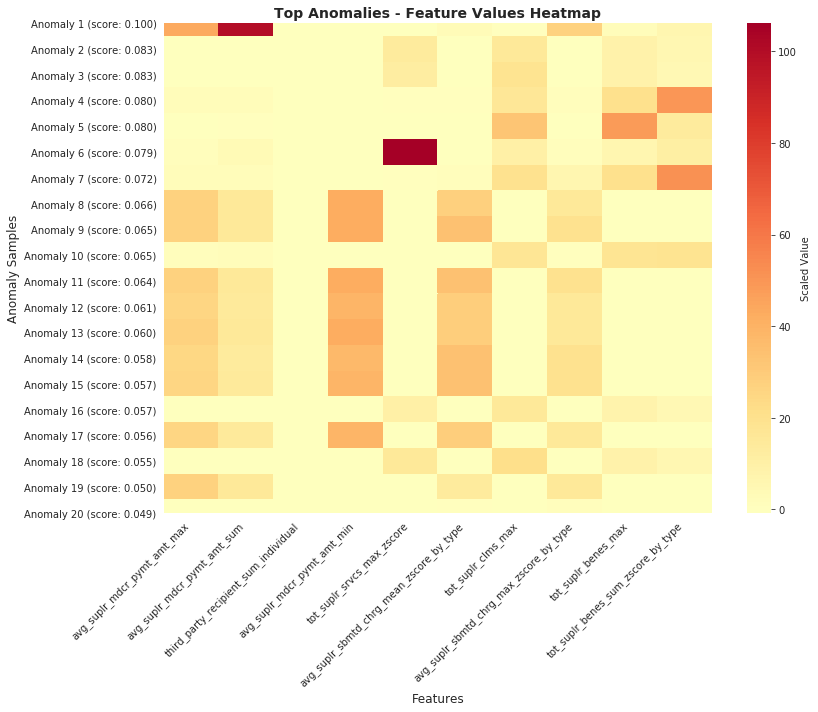

In [23]:
# Select top anomalies by highest score
n_top_anomalies = 20
top_anomaly_indices = np.argsort(test_scores)[-n_top_anomalies:][::-1]

# Get top features
top_feature_names = importance_df.head(10)['feature'].values
top_feature_indices = [feature_cols.index(f) for f in top_feature_names]

# Create heatmap data
heatmap_data = X_test_scaled[top_anomaly_indices][:, top_feature_indices]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            xticklabels=top_feature_names, 
            yticklabels=[f"Anomaly {i+1} (score: {test_scores[idx]:.3f})" 
                         for i, idx in enumerate(top_anomaly_indices)],
            cmap='RdYlGn_r', 
            center=0,
            cbar_kws={'label': 'Scaled Value'})
plt.title('Top Anomalies - Feature Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Anomaly Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('isolation_forest_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics and Recommendations

In [24]:
print("ISOLATION FOREST FRAUD DETECTION SUMMARY")
print(f"\nModel Configuration (AUPRC-Tuned):")
print(f"  - n_estimators: {best_params['n_estimators']}")
print(f"  - max_samples: {best_params['max_samples']}")
print(f"  - contamination: {best_params['contamination']}")
print(f"  - Best AUPRC: {best_auprc:.4f} (+/- {best_auprc_std:.4f})")
print(f"  - Features Used: {len(feature_cols)}")

print(f"\nDataset:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")
print(f"  - Fraud in Training: {y_train.sum()}")
print(f"  - Fraud in Test: {y_test.sum()}")

print(f"\nAnomaly Detection Results (Test Set):")
print(f"  - Normal Transactions: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(test_predictions)*100:.2f}%)")
print(f"  - Anomalous Transactions: {(test_predictions == -1).sum()} ({(test_predictions == -1).sum()/len(test_predictions)*100:.2f}%)")

print(f"\nTop 5 Discriminative Features:")
for idx, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:40s} | Importance: {row['importance']:.4f} | Δ: {row['difference']:+.4f}")

print(f"\nPCA Visualization:")
print(f"  - Variance Explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Variance Explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

ISOLATION FOREST FRAUD DETECTION SUMMARY

Model Configuration (AUPRC-Tuned):
  - n_estimators: 100
  - max_samples: 1.0
  - contamination: 0.002
  - Best AUPRC: 0.0015 (+/- 0.0011)
  - Features Used: 64

Dataset:
  - Total Samples: 140827
  - Training Samples: 84496
  - Test Samples: 56331
  - Fraud in Training: 34
  - Fraud in Test: 22

Anomaly Detection Results (Test Set):
  - Normal Transactions: 56211 (99.79%)
  - Anomalous Transactions: 120 (0.21%)

Top 5 Discriminative Features:
  avg_suplr_mdcr_pymt_amt_max              | Importance: 7.3328 | Δ: +7.3328
  avg_suplr_mdcr_pymt_amt_sum              | Importance: 7.1299 | Δ: +7.1299
  third_party_recipient_sum_individual     | Importance: 6.8337 | Δ: +6.8337
  avg_suplr_mdcr_pymt_amt_min              | Importance: 6.5760 | Δ: +6.5760
  tot_suplr_srvcs_max_zscore               | Importance: 6.3101 | Δ: +6.3101

PCA Visualization:
  - Variance Explained by PC1: 16.56%
  - Variance Explained by PC2: 10.94%
  - Total Variance Explained:

## AUPRC Evaluation on Test Set

Test Set AUPRC: 0.0017
(Random baseline AUPRC ≈ 0.000391)


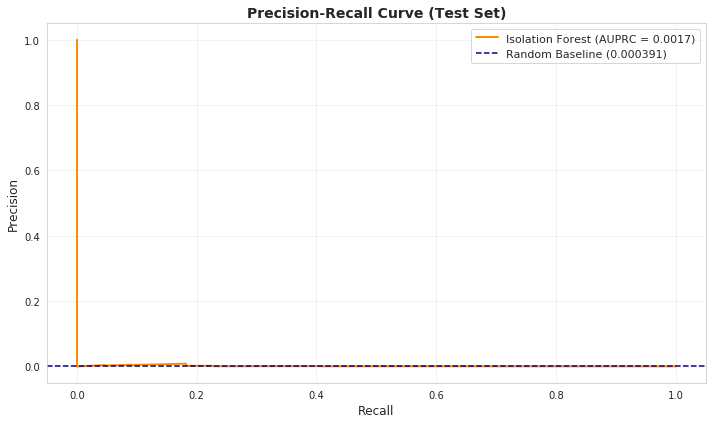

In [25]:
##############################################
# Evaluate AUPRC on test set using known fraud labels
###############################################
test_auprc = average_precision_score(y_test, test_scores)
print(f"Test Set AUPRC: {test_auprc:.4f}")
print(f"(Random baseline AUPRC ≈ {y_test.mean():.6f})")

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, color='darkorange', label=f'Isolation Forest (AUPRC = {test_auprc:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--', label=f'Random Baseline ({y_test.mean():.6f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (Test Set)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('isolation_forest_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix (Top 5% Anomalous as Predicted Fraud)

Top 5% anomaly score threshold: -0.0737
Samples flagged as fraud (top 5%): 2817
Actual fraud in test set: 22

Confusion Matrix (top 5% threshold):
[[53497  2812]
 [   17     5]]

Classification Report (top 5% threshold):
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.95      0.97     56309
     Fraud (1)       0.00      0.23      0.00        22

      accuracy                           0.95     56331
     macro avg       0.50      0.59      0.49     56331
  weighted avg       1.00      0.95      0.97     56331



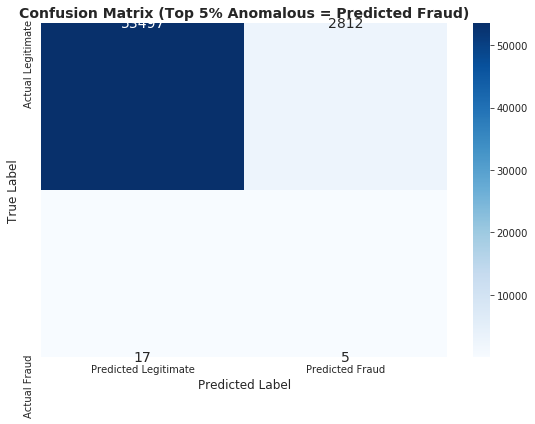


Detailed Metrics:
  True Positives (fraud caught): 5
  False Positives (legitimate flagged): 2812
  True Negatives (legitimate correct): 53497
  False Negatives (fraud missed): 17
  Precision: 0.0018
  Recall: 0.2273
  Fraud capture rate in top 5%: 5/22 = 22.7%


In [26]:
##############################################
# Confusion Matrix: top 5% most anomalous = predicted fraud (1)
###############################################
top_5pct_threshold = np.percentile(test_scores, 95)
y_pred_top5 = (test_scores >= top_5pct_threshold).astype(int)

print(f"Top 5% anomaly score threshold: {top_5pct_threshold:.4f}")
print(f"Samples flagged as fraud (top 5%): {y_pred_top5.sum()}")
print(f"Actual fraud in test set: {y_test.sum()}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_top5)
print(f"\nConfusion Matrix (top 5% threshold):")
print(cm)

# Classification report
print(f"\nClassification Report (top 5% threshold):")
print(classification_report(y_test, y_pred_top5, target_names=['Legitimate (0)', 'Fraud (1)']))

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Top 5% Anomalous = Predicted Fraud)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('isolation_forest_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Metrics:")
print(f"  True Positives (fraud caught): {tp}")
print(f"  False Positives (legitimate flagged): {fp}")
print(f"  True Negatives (legitimate correct): {tn}")
print(f"  False Negatives (fraud missed): {fn}")
print(f"  Precision: {tp/(tp+fp):.4f}" if (tp+fp) > 0 else "  Precision: N/A")
print(f"  Recall: {tp/(tp+fn):.4f}" if (tp+fn) > 0 else "  Recall: N/A")
print(f"  Fraud capture rate in top 5%: {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%" if (tp+fn) > 0 else "")

## Save Model and Artifacts for Ensemble Integration

In [27]:
# Save the trained model
joblib.dump(iso_forest, 'isolation_forest_model.pkl')
print("Model saved to 'isolation_forest_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'isolation_forest_scaler.pkl')
print("Scaler saved to 'isolation_forest_scaler.pkl'")

# Save reference scores for z-score normalization in ensemble
reference_data = {
    'train_scores': train_scores,
    'train_mean': float(train_scores.mean()),
    'train_std': float(train_scores.std()),
    'threshold': float(np.percentile(train_scores, 95)),
    'feature_cols': feature_cols,
    'feature_importance': importance_df.set_index('feature')['importance'].to_dict(),
    'best_params': best_params,
    'best_auprc': float(best_auprc),
    'best_auprc_std': float(best_auprc_std)
}
joblib.dump(reference_data, 'isolation_forest_reference_scores.pkl')
print("Reference scores saved to 'isolation_forest_reference_scores.pkl'")

print(f"\nReference Statistics:")
print(f"  - Training Score Mean: {reference_data['train_mean']:.4f}")
print(f"  - Training Score Std: {reference_data['train_std']:.4f}")
print(f"  - 95th Percentile Threshold: {reference_data['threshold']:.4f}")

Model saved to 'isolation_forest_model.pkl'
Scaler saved to 'isolation_forest_scaler.pkl'
Reference scores saved to 'isolation_forest_reference_scores.pkl'

Reference Statistics:
  - Training Score Mean: -0.1117
  - Training Score Std: 0.0216
  - 95th Percentile Threshold: -0.0731


In [28]:
# Create output DataFrame with predictions and scores
output_df = X_test.copy()
output_df['anomaly_score'] = test_scores
output_df['is_anomaly'] = (test_predictions == -1).astype(int)
output_df['prediction'] = test_predictions

# Sort by anomaly score (most anomalous first)
output_df = output_df.sort_values('anomaly_score', ascending=False)

print("Top 10 Most Anomalous Samples:")
print(output_df[['anomaly_score', 'is_anomaly', 'prediction']].head(10))

# Export to CSV
output_df.to_csv('isolation_forest_predictions.csv', index=True)
print("\nPredictions exported to 'isolation_forest_predictions.csv'")

Top 10 Most Anomalous Samples:
        anomaly_score  is_anomaly  prediction
8450         0.099686           1          -1
21963        0.083345           1          -1
26917        0.082846           1          -1
119908       0.080076           1          -1
134666       0.079726           1          -1
135609       0.079442           1          -1
119907       0.072343           1          -1
138180       0.066263           1          -1
228          0.065268           1          -1
86211        0.064924           1          -1

Predictions exported to 'isolation_forest_predictions.csv'
